In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import special as sp
from scipy import integrate
from scipy.signal import savgol_filter
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# Stabilization of EH Self Acceleration

In [9]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

Ea_s = 5
Ea_e = 505

dt = 0.05
max_steps = 30000
data_steps = int(max_steps / 1)
data_num = int(max_steps / data_steps) + 1

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00004"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00006"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E0001"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00012"

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t105"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t205"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t405"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\uniformE_E00008_t505"

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E01" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_t205" 

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-015" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-0125" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-0075" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ui-005"  

# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue004" 
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue002" 
path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue-002"
# path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\sinE_E03_Ue-005"

print(data_num)
print("real time = ", max_steps * dt)

2
real time =  1500.0


In [10]:
phi = np.loadtxt(os.path.join(path, "Phi_evolution"))[:,0:max_steps]
t = np.linspace(0, max_steps, max_steps)*dt

In [11]:
fe_final = np.loadtxt(os.path.join(path,"fe1"))
lve = np.linspace(fe_final.min(),fe_final.max(),num=25)

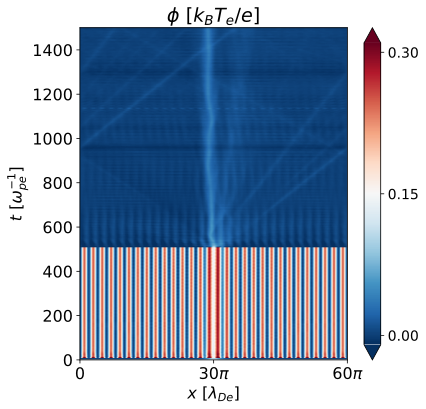

In [12]:
T, X = np.meshgrid(t, x)

fig = plt.figure(figsize=(6, 6))
cb = plt.pcolormesh(X, T, phi, vmin=-0.01, vmax=0.31, cmap=cm.RdBu_r, rasterized=True)

plt.ylabel(r"$t~[\omega_{pe}^{-1}]$")
plt.xlabel(r"$x~[\lambda_{De}]$")
plt.xticks([0, 30*np.pi, 60*np.pi], ["0", r"$30\pi$", r"$60\pi$"])

cbar = plt.colorbar(cb, ticks=[0.0, 0.15, 0.3], extend="both")
cbar.ax.tick_params(labelsize=14)
plt.title(r"$\phi~[k_B T_e/e]$")
plt.show()

C:\Users\RGuo\AppData\Local\Temp\ipykernel_7420\4131880739.py:6: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x000001A08EAD9CD0>' will be ignored
  ax1cmp.set_rasterized(True)


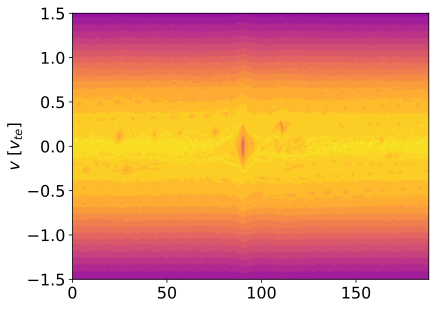

In [13]:
x_ticks=[0, 15*np.pi, 30*np.pi, 45*np.pi, 60*np.pi]

ax1cmp = plt.contourf(Xe, Ve, fe_final, levels=lve,extend='both',cmap=cm.plasma)
plt.ylabel(r'$v~[v_{te}]$')
plt.ylim(-1.5,1.5)
ax1cmp.set_rasterized(True)

plt.show()

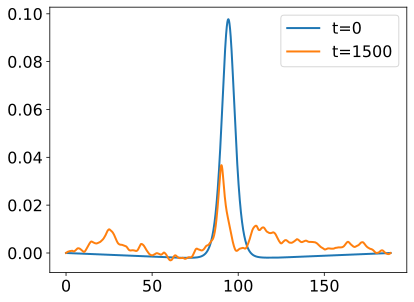

In [14]:
plt.plot(x, phi[:,0],label="t=0")
plt.plot(x, phi[:,-1],label="t=1500")
plt.legend()